In [488]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

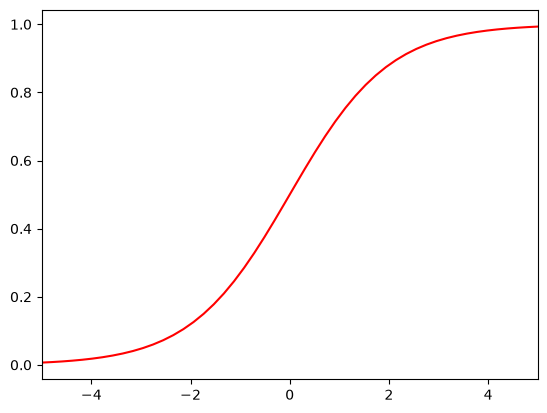

In [489]:
x = torch.linspace(-5, 5, 50)
y = torch.sigmoid(x)

plt.plot(x, y, 'r-')
plt.xlim([-5, 5])
plt.show()

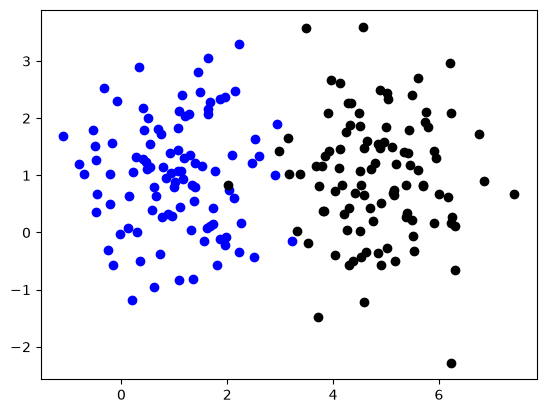

In [490]:
# Experiment 1: Create a neural network capable of binary classification
N = 100
A = [1, 1]
B = [5, 1]
blur = 1

a = [A[0] + np.random.randn(N) * blur, A[1] + np.random.randn(N) * blur]
b = [B[0] + np.random.randn(N) * blur, B[1] + np.random.randn(N) * blur]
data_np = np.hstack((a, b)).T
data = torch.tensor(data_np).float()

labels_np = np.vstack((np.zeros((N, 1)), np.ones((N, 1))))
labels = torch.tensor(labels_np).float()

plt.plot(data_np[np.where(labels_np == 0)[0], 0], data_np[np.where(labels_np == 0)[0], 1], 'bo')
plt.plot(data_np[np.where(labels_np == 1)[0], 0], data_np[np.where(labels_np == 1)[0], 1], 'ko')
plt.show()

In [491]:
nn_classifier = nn.Sequential(
    nn.Linear(2, 1),
    nn.ReLU(),
    nn.Linear(1, 1),
    nn.Sigmoid()
)
loss_func = nn.BCELoss()
learning_rate = 0.02
optimizer = torch.optim.SGD(nn_classifier.parameters(), lr=learning_rate)

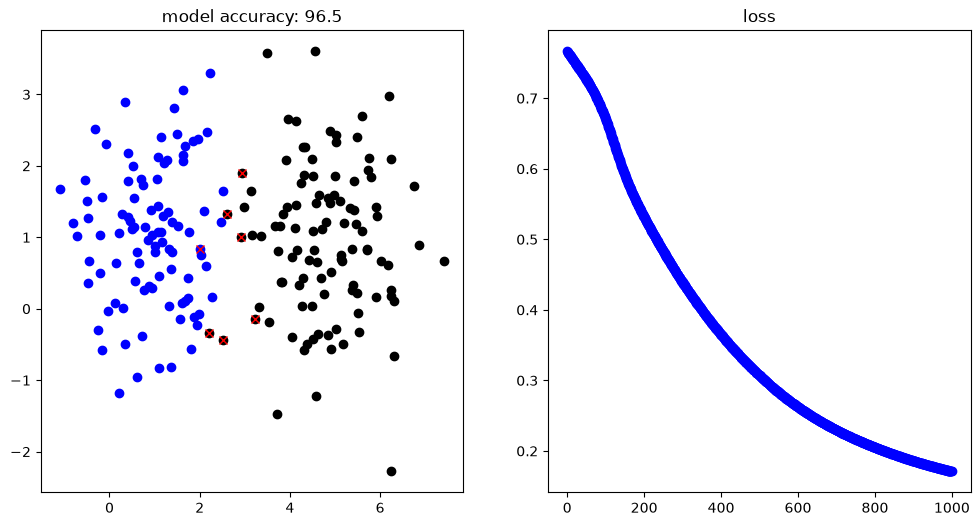

In [492]:
training_epochs = 1000
losses = np.zeros(training_epochs)

for epoch in range(training_epochs):
    # forward pass
    y_hat = nn_classifier(data)

    # loss function
    loss = loss_func(y_hat, labels)
    losses[epoch] = loss

    # backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

predictions = nn_classifier(data)
prediction_labels = predictions > 0.5
misclassifications = np.where(prediction_labels != labels)[0]
accuracy = 100 - 100 * len(misclassifications) / (N*2)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].plot(data_np[np.where(prediction_labels == 0)[0], 0], 
           data_np[np.where(prediction_labels == 0)[0], 1], 'bo')

ax[0].plot(data_np[np.where(prediction_labels == 1)[0], 0], 
           data_np[np.where(prediction_labels == 1)[0], 1], 'ko')

ax[0].plot(data_np[misclassifications, 0], data_np[misclassifications, 1], 'rx')
ax[0].set_title('model accuracy: ' + str(accuracy))

ax[1].plot(losses, 'bo')
ax[1].set_title('loss')

plt.show()

[98.  98.  98.  91.5 99.  97.5 49.  99.  89.5 98.  99.  98.5 98.  91.
 99.  98.  99.  50.  50.  49.5]


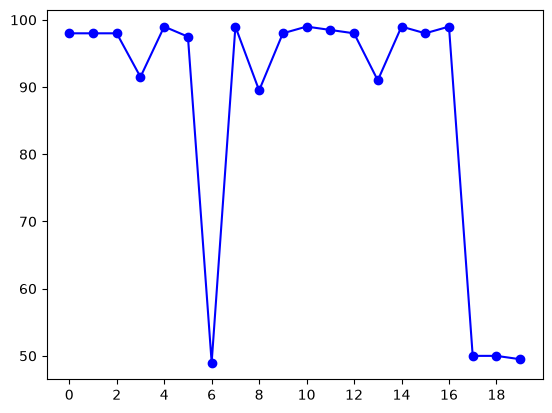

In [493]:
# Observation: this neural network displays very inconsistent results for binary classification. After being trained, the model alternates between an accuracy of 90% and 50% (basically just guessing).

iterations = 20
model_accuracy = np.zeros(iterations)

for iter in range(iterations):
    nn_classifier = nn.Sequential(
        nn.Linear(2,1),
        nn.ReLU(),
        nn.Linear(1, 1),
        nn.Sigmoid()
    )
    loss_func = nn.BCELoss()
    learning_rate = 0.02
    optimizer = torch.optim.SGD(nn_classifier.parameters(), lr=learning_rate)

    training_epochs = 2000
    for epoch in range(training_epochs):
        # forward pass
        y_hat = nn_classifier(data)

        # loss function
        loss = loss_func(y_hat, labels)

        # backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    predictions = nn_classifier(data);
    prediction_labels = predictions > 0.5
    misclassifications = np.where(prediction_labels != labels)[0]
    accuracy = 100 - 100 * (len(misclassifications) / len(labels))
    model_accuracy[iter] = accuracy

print(model_accuracy)
plt.plot(model_accuracy, "bo-")
plt.xticks(range(0, 20, 2))
plt.show()

[98.  98.  98.  98.  98.  98.  98.  98.  98.  98.  98.  98.  98.  98.
 98.  98.  98.  98.  97.5 98. ]


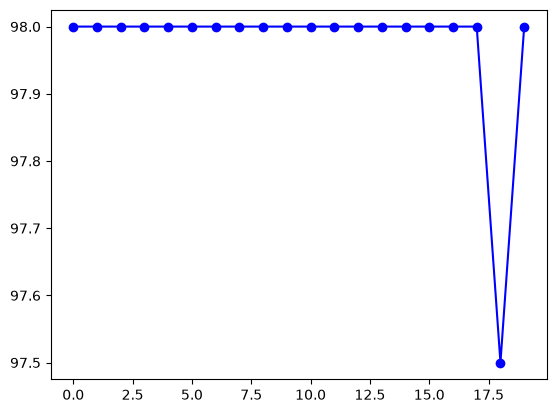

In [494]:
# Experiment 2:  Create a neural network CONSISTENTLY capable of binary classification

# The problem with the previous Neural Network comes from using ReLU as the an activation function. If the linear function before it returns a negative number, ReLU will always return zero. This can fuck up the model during training.

iterations = 20
model_accuracy = np.zeros(iterations)

for iter in range(iterations):
    nn_classifier = nn.Sequential(
        nn.Linear(2,1),
        #nn.ReLU(), Removing this improves model consistentcy (by a lot!)
        nn.Linear(1, 1),
        nn.Sigmoid()
    )
    loss_func = nn.BCELoss()
    learning_rate = 0.02
    optimizer = torch.optim.SGD(nn_classifier.parameters(), lr=learning_rate)

    training_epochs = 2000
    for epoch in range(training_epochs):
        # forward pass
        y_hat = nn_classifier(data)

        # loss function
        loss = loss_func(y_hat, labels)

        # backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    predictions = nn_classifier(data);
    prediction_labels = predictions > 0.5
    misclassifications = np.where(prediction_labels != labels)[0]
    accuracy = 100 - 100 * (len(misclassifications) / len(labels))
    model_accuracy[iter] = accuracy

print(model_accuracy)
plt.plot(model_accuracy, "bo-")
plt.show()
